<a href="https://colab.research.google.com/github/Lilly-jhr/Genetic-Programming/blob/main/GP_with_boolean_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genetic Programming with Boolean Expression

The system's goal is to automatically discover a target boolean expression that correctly maps a set of inputs to outputs. It demonstrates the core GP principles of population initialization, fitness evaluation, selection, crossover, and mutation.

Generating dataset for 4 variables (16 combinations)...
--- Dataset (Target: ((a AND b) OR (NOT c)) AND d) ---
Inputs: {'a': 0, 'b': 0, 'c': 0, 'd': 0}, Target Output: 0
Inputs: {'a': 0, 'b': 0, 'c': 0, 'd': 1}, Target Output: 1
Inputs: {'a': 0, 'b': 0, 'c': 1, 'd': 0}, Target Output: 0
Inputs: {'a': 0, 'b': 0, 'c': 1, 'd': 1}, Target Output: 0
Inputs: {'a': 0, 'b': 1, 'c': 0, 'd': 0}, Target Output: 0
...
Inputs: {'a': 1, 'b': 0, 'c': 1, 'd': 1}, Target Output: 0
Inputs: {'a': 1, 'b': 1, 'c': 0, 'd': 0}, Target Output: 0
Inputs: {'a': 1, 'b': 1, 'c': 0, 'd': 1}, Target Output: 1
Inputs: {'a': 1, 'b': 1, 'c': 1, 'd': 0}, Target Output: 0
Inputs: {'a': 1, 'b': 1, 'c': 1, 'd': 1}, Target Output: 1
------------------------------

Starting GP...
Parameters: Pop Size=250, Gens=150, Max Initial Depth=5, Max Evo Depth=10, Tourn Size=2, CX Rate=0.85, Mut Rate=0.1, Elitism=1
------------------------------

Starting GP run for 150 generations...
Generation 0: New best fitness = 3.00, Avg Fitness

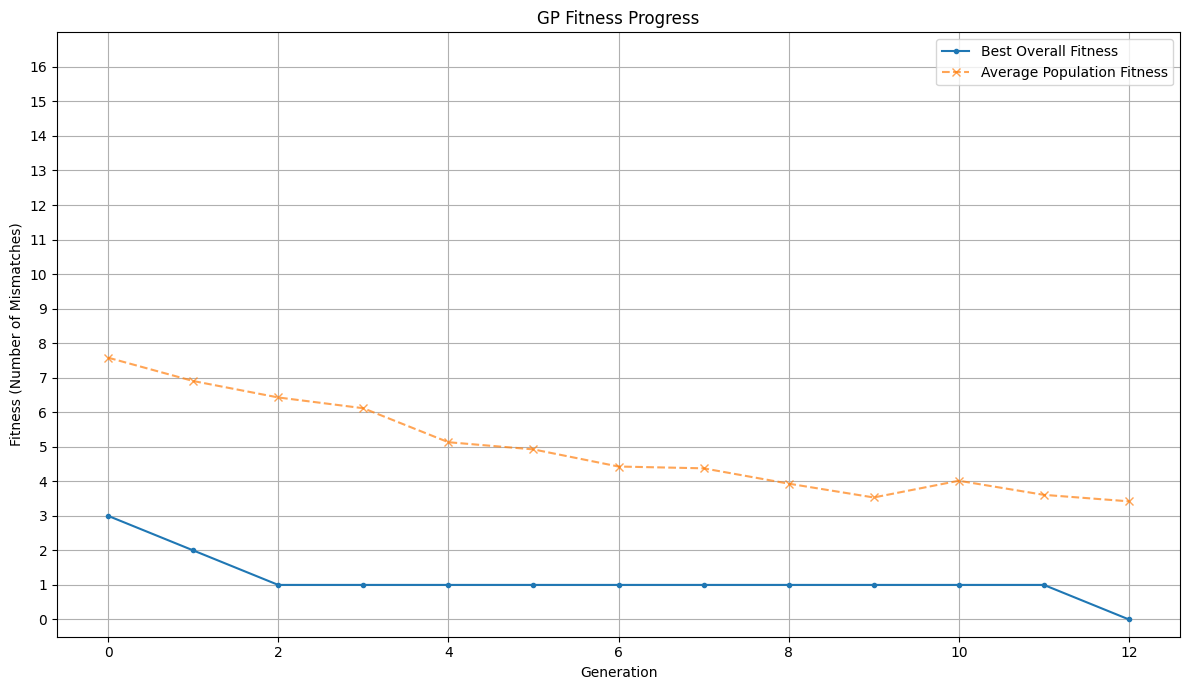

In [16]:
import random
import math
import copy
import matplotlib.pyplot as plt
import numpy as np
# 1. Dataset Definition


VARIABLES = ['a', 'b', 'c', 'd']

# the target boolean expression (for generating the dataset)
def target_function(vals):
    a = vals['a']
    b = vals['b']
    c = vals['c']
    d = vals['d']
    # Expression: ((a AND b) OR (NOT c)) AND d
    return int(((a and b) or (not c)) and d)

# all possible input combinations and their outputs
DATASET = []
num_vars = len(VARIABLES)
print(f"Generating dataset for {num_vars} variables ({2**num_vars} combinations)...")
for i in range(2**num_vars):
    # binary representation for the input combination
    binary = bin(i)[2:].zfill(num_vars)

    input_vals = {VARIABLES[j]: int(binary[j]) for j in range(num_vars)}
    output_val = target_function(input_vals)
    DATASET.append({'inputs': input_vals, 'output': output_val})

print("--- Dataset (Target: ((a AND b) OR (NOT c)) AND d) ---")
if len(DATASET) > 10:
    for row in DATASET[:5]:
        print(f"Inputs: {row['inputs']}, Target Output: {row['output']}")
    print("...")
    for row in DATASET[-5:]:
        print(f"Inputs: {row['inputs']}, Target Output: {row['output']}")
else:
     for row in DATASET:
        print(f"Inputs: {row['inputs']}, Target Output: {row['output']}")
print("-" * 30)


# 2. GP System Components

FUNCTION_SET = ['AND', 'OR', 'NOT']
TERMINAL_SET = VARIABLES


class Node:
    """ Represents a node in the expression tree. """
    def __init__(self, value, children=None):
        self.value = value
        self.children = children if children else []

    def __str__(self):
        """ String representation for easy printing/debugging. """
        if self.value in TERMINAL_SET:
            return self.value
        elif self.value == 'NOT':
            child_str = str(self.children[0]) if self.children else "None"
            return f"NOT({child_str})"
        elif self.value in ['AND', 'OR']:
            left_str = str(self.children[0]) if len(self.children) > 0 else "None"
            right_str = str(self.children[1]) if len(self.children) > 1 else "None"
            return f"({left_str} {self.value} {right_str})"
        else:
            return "INVALID_NODE"

# Tree Generation (Initialization)
def create_random_terminal():
    """ Creates a random terminal node. """
    return Node(random.choice(TERMINAL_SET))

def create_random_function():
    """ Returns a random function name. """
    return random.choice(FUNCTION_SET)

def create_random_tree(max_depth, current_depth=0, method='grow'):
    """
    Creates a random expression tree using 'grow' or 'full' method.
    """
    #  max depth reached or it's a terminal chosen by 'grow' method at non-max depth
    if current_depth >= max_depth - 1 or (method == 'grow' and random.random() < 0.4 and current_depth > 0): # Allow terminals earlier in grow
        return create_random_terminal()

    # If 'full' method, always choose a function unless at max depth
    # If 'grow' method and not chosen terminal above, choose function
    is_function = True
    if method == 'grow':
         # Let's make grow method slightly more balanced
         # prob_terminal = 0.4 if current_depth < max_depth / 2 else 0.6
         # if random.random() < prob_terminal:
         #     is_function = False # Actually handled above now
         pass # Simplified: if not terminal above, it's function for grow

    # Ensure the root is likely a function unless max_depth is 1
    if current_depth == 0 and max_depth > 1:
         is_function = True

    if not is_function: # only happen if max_depth is 1
        return create_random_terminal()
    else: # Create a function node
        func = create_random_function()
        if func == 'NOT':
            child = create_random_tree(max_depth, current_depth + 1, method)
            while child is None: # Should not happen but safety check
                 child = create_random_tree(max_depth, current_depth + 1, method)
            return Node(func, [child])
        else: # 'AND', 'OR' - Binary operators
            left_child = create_random_tree(max_depth, current_depth + 1, method)
            right_child = create_random_tree(max_depth, current_depth + 1, method)
            while left_child is None: # Safety checks
                 left_child = create_random_tree(max_depth, current_depth + 1, method)
            while right_child is None: # Safety checks
                 right_child = create_random_tree(max_depth, current_depth + 1, method)
            return Node(func, [left_child, right_child])


def initialize_population(size, max_depth):
    """ Creates the initial population of random trees using Ramped Half-and-Half. """
    population = []
    half_size = size // 2

    effective_max_depth = max(1, max_depth)

    for depth in range(1, effective_max_depth + 1): # Ramping depth
        for _ in range(size // (2 * effective_max_depth)): # distribute individuals across depths
             population.append(create_random_tree(depth, method='grow'))
             if len(population) < size:
                 population.append(create_random_tree(depth, method='full'))

    # Fill remaining spots if size is not perfectly divisible
    while len(population) < size:
         # Use grow/full mix for remaining ones at max_depth
         method = 'grow' if random.random() < 0.5 else 'full'
         population.append(create_random_tree(effective_max_depth, method=method))

    return population[:size] # ensure exact size


# Evaluation
def evaluate_tree(tree, input_values):
    """
    Recursively evaluates the expression tree for given input values.
    Handles potential None children defensively.
    """
    if tree is None:
         raise ValueError("Attempted to evaluate a None tree/subtree.")

    if tree.value in TERMINAL_SET:
        if tree.value not in input_values:
             raise ValueError(f"Terminal '{tree.value}' not found in input values: {input_values}")
        return input_values[tree.value]

    elif tree.value == 'NOT':
        if not tree.children: raise ValueError("NOT node has no children.")
        child_val = evaluate_tree(tree.children[0], input_values)
        return int(not child_val)

    elif tree.value == 'AND':
        if len(tree.children) < 2: raise ValueError("AND node has insufficient children.")
        left_val = evaluate_tree(tree.children[0], input_values)
        right_val = evaluate_tree(tree.children[1], input_values)
        return int(left_val and right_val)

    elif tree.value == 'OR':
        if len(tree.children) < 2: raise ValueError("OR node has insufficient children.")
        left_val = evaluate_tree(tree.children[0], input_values)
        right_val = evaluate_tree(tree.children[1], input_values)
        return int(left_val or right_val)

    else:
        raise ValueError(f"Unknown node value during evaluation: {tree.value}")



def calculate_fitness(tree, dataset):
    """
    Calculates the fitness of a tree based on how many dataset entries it matches.
    Fitness = number of mismatches (lower is better, 0 is perfect).
    """
    mismatches = 0
    max_mismatches = len(dataset)
    for row in dataset:
        try:
            predicted_output = evaluate_tree(tree, row['inputs'])
            if predicted_output != row['output']:
                mismatches += 1
        except RecursionError:
             # Penalize excessively deep trees that cause recursion errors
             return max_mismatches + 1 # Worse than max mismatches
        except ValueError as e:
             # Penalize trees that are structurally invalid during evaluation
             return max_mismatches + 2 # Even worse fitness
        except Exception as e: # Catch other potential errors
             return max_mismatches + 3 # Worst fitness

    # Ensure fitness is never negative (shouldn't happen with mismatches)
    return max(0, mismatches)


# Selection
def tournament_selection(population, fitnesses, tournament_size):
    """ Selects an individual using tournament selection. """

    actual_tournament_size = min(tournament_size, len(population))
    if actual_tournament_size <= 0:
         # Fallback: If population is empty or tournament size is non-positive, return None or raise error
         return None

    try:
         selected_indices = random.sample(range(len(population)), actual_tournament_size)
    except ValueError:
         if not population: return None
         selected_indices = list(range(len(population))) # Use the whole population if sample fails


    best_index = selected_indices[0]
    try:
        min_fitness = fitnesses[best_index]
        if not isinstance(min_fitness, (int, float)): min_fitness = float('inf')
    except IndexError:
         # This should not happen if population and fitnesses are aligned
         return None

    for i in selected_indices[1:]:
        try:
            current_fitness = fitnesses[i]
            if isinstance(current_fitness, (int, float)) and current_fitness < min_fitness:
                min_fitness = current_fitness
                best_index = i
        except IndexError:
             continue

    # Return a *copy* to avoid modifying the original selected individual
    # if it's selected multiple times or used directly as elite later
    try:
         return copy.deepcopy(population[best_index])
    except IndexError:
         return None


# Variation (Crossover and Mutation)

def get_all_nodes_with_depth(tree, current_depth, nodes_list):
    """ Recursively collect all nodes and their depths in a tree. """
    if tree is None: return
    nodes_list.append((tree, current_depth))
    for child in tree.children:
        get_all_nodes_with_depth(child, current_depth + 1, nodes_list)

def calculate_depth(tree):
    """ Calculates the maximum depth of a tree. """
    if tree is None or not tree.children:
        return 1
    return 1 + max(calculate_depth(child) for child in tree.children)


# Crossover
def crossover(parent1, parent2, max_allowed_depth):
    """ Performs subtree crossover between two parent trees, respecting max depth. """
    offspring1 = copy.deepcopy(parent1)
    offspring2 = copy.deepcopy(parent2)

    nodes1_with_depth = []
    get_all_nodes_with_depth(offspring1, 0, nodes1_with_depth)
    if not nodes1_with_depth: return parent1, parent2 # Return originals if empty

    nodes2_with_depth = []
    get_all_nodes_with_depth(offspring2, 0, nodes2_with_depth)
    if not nodes2_with_depth: return parent1, parent2 # Return originals if empty

    # Try multiple times to find a valid crossover point respecting depth limits
    for _ in range(10): # limit attempts to prevent infinite loops
        # Select random nodes (references within the copied trees)
        node1_ref, depth1 = random.choice(nodes1_with_depth)
        node2_ref, depth2 = random.choice(nodes2_with_depth)

        # Calculate the depth of the subtrees being swapped
        subtree1_depth = calculate_depth(node1_ref)
        subtree2_depth = calculate_depth(node2_ref)

        # Check if swapping violates max_allowed_depth
        if depth1 + subtree2_depth <= max_allowed_depth and \
           depth2 + subtree1_depth <= max_allowed_depth:

            temp_value = node1_ref.value
            temp_children = node1_ref.children
            node1_ref.value = node2_ref.value
            node1_ref.children = node2_ref.children
            node2_ref.value = temp_value
            node2_ref.children = temp_children
            return offspring1, offspring2

    # If no valid swap found after attempts, return original parents (or copies)
    return parent1, parent2


# Mutation
def mutation(tree, generation_method_max_depth, max_allowed_depth, mutation_rate):
    """ Performs subtree mutation on a tree, respecting max depth. """
    if random.random() < mutation_rate:
        mutated_tree = copy.deepcopy(tree)

        nodes_with_depth = []
        get_all_nodes_with_depth(mutated_tree, 0, nodes_with_depth)
        if not nodes_with_depth: return tree

        for _ in range(10):
            mutation_point_ref, depth = random.choice(nodes_with_depth)

            # Generate a new random subtree
            max_subtree_depth = max(1, max_allowed_depth - depth)
            # Use the generation method's max depth as an upper bound too, and ensure positive
            gen_depth = max(1, min(max_subtree_depth, generation_method_max_depth // 2 + 1))

            replacement_subtree = create_random_tree(gen_depth, method='grow')

            # Perform the replacement (value and children)
            mutation_point_ref.value = replacement_subtree.value
            mutation_point_ref.children = replacement_subtree.children

            if calculate_depth(mutated_tree) <= max_allowed_depth:
                 return mutated_tree

        # If mutation failed to respect depth limit after attempts, return original tree
        return tree
    else:
        return tree # Return original tree if no mutation roll


# GP Execution
def run_gp(population_size, generations, initial_max_depth, evolution_max_depth, tournament_size, crossover_rate, mutation_rate, elitism_count):
    """ Runs the Genetic Programming algorithm. """

    population = initialize_population(population_size, initial_max_depth)
    best_fitness_overall = float('inf')
    best_individual_overall = None
    best_fitness_history = []
    avg_fitness_history = []

    print(f"\nStarting GP run for {generations} generations...")
    for gen in range(generations):
        fitnesses = []
        valid_population = [] # to track individuals that evaluated successfully
        max_possible_fitness = len(DATASET) + 3 # Upper bound for error penalties

        for ind in population:
             fit = calculate_fitness(ind, DATASET)

             if isinstance(fit, (int, float)) and fit <= len(DATASET):
                 fitnesses.append(fit)
                 valid_population.append(ind)


        if not valid_population:
             print(f"Generation {gen}: Entire population failed evaluation. Stopping.")
             break

        population = valid_population # Update population to only include valid ones

        # Calculate stats for the current valid population
        min_fitness_gen = min(fitnesses) if fitnesses else float('inf')
        avg_fitness_gen = np.mean(fitnesses) if fitnesses else float('inf')
        best_index_gen = fitnesses.index(min_fitness_gen) if fitnesses else -1

        avg_fitness_history.append(avg_fitness_gen)

        # Update overall best
        if min_fitness_gen < best_fitness_overall:
            best_fitness_overall = min_fitness_gen
            if best_index_gen != -1:
                 best_individual_overall = copy.deepcopy(population[best_index_gen])
                 print(f"Generation {gen}: New best fitness = {best_fitness_overall:.2f}, Avg Fitness: {avg_fitness_gen:.2f}, Tree: {str(best_individual_overall)[:100]}...") # Print truncated tree
            else:
                 print(f"Generation {gen}: Error finding best individual index.")

        # Print progress periodically even if no improvement
        else:
             print(f"Generation {gen}: Current best fitness = {min_fitness_gen:.2f}, Avg Fitness = {avg_fitness_gen:.2f}, Overall best = {best_fitness_overall:.2f}")

        best_fitness_history.append(best_fitness_overall)

        # Check for perfect solution
        if best_fitness_overall == 0:
            print(f"\nPerfect solution found in generation {gen}!")
            break

        # Create next generation
        new_population = []

        # Elitism: Copy the best individuals directly from the *valid* population
        actual_elitism_count = min(elitism_count, len(population))
        if actual_elitism_count > 0:
            # Get indices of the best individuals based on 'fitnesses' list
            elite_indices = sorted(range(len(fitnesses)), key=lambda k: fitnesses[k])[:actual_elitism_count]
            for i in elite_indices:
                try:
                    new_population.append(copy.deepcopy(population[i]))
                except IndexError:
                     print(f"Warning: Elite index {i} out of bounds for population size {len(population)}.")
                     continue


        # Fill the rest of the population using selection, crossover, mutation
        # Adjust population size target if some individuals were discarded
        target_pop_size = population_size

        while len(new_population) < target_pop_size:
            # Selection (from valid population and corresponding fitnesses)
            parent1 = tournament_selection(population, fitnesses, tournament_size)
            if parent1 is None: continue # Skip if selection failed

            # Decide Crossover or Mutation/Reproduction
            if random.random() < crossover_rate and len(new_population) < target_pop_size :
                 parent2 = tournament_selection(population, fitnesses, tournament_size)
                 if parent2 is None: # If second parent selection fails, fallback to mutation
                      mutated_offspring = mutation(parent1, initial_max_depth, evolution_max_depth, mutation_rate)
                      new_population.append(mutated_offspring)
                      continue

                 # Crossover produces two offspring
                 offspring1, offspring2 = crossover(parent1, parent2, evolution_max_depth)

                 # Apply mutation to both offspring
                 mutated_offspring1 = mutation(offspring1, initial_max_depth, evolution_max_depth, mutation_rate)
                 mutated_offspring2 = mutation(offspring2, initial_max_depth, evolution_max_depth, mutation_rate)

                 new_population.append(mutated_offspring1)
                 if len(new_population) < target_pop_size:
                     new_population.append(mutated_offspring2)

            else:
                # Mutation only
                mutated_offspring = mutation(parent1, initial_max_depth, evolution_max_depth, mutation_rate)
                new_population.append(mutated_offspring)


        # Replace old population with the new generation
        population = new_population
        population = population[:target_pop_size]


    print("\nGP run finished.")
    # If loop finished without finding a perfect solution, best_individual_overall holds the best found
    if best_individual_overall is None and population:
         # Fallback if no improvement was ever recorded (e.g., finished gen 0 and stopped)
         final_fitnesses = [calculate_fitness(ind, DATASET) for ind in population if calculate_fitness(ind, DATASET) <= len(DATASET)]
         if final_fitnesses:
             final_best_idx = final_fitnesses.index(min(final_fitnesses))
             # Find the corresponding individual in the original population list
             valid_indices = [i for i, ind in enumerate(population) if calculate_fitness(ind, DATASET) <= len(DATASET)]
             actual_best_idx = valid_indices[final_best_idx]

             best_individual_overall = population[actual_best_idx]
             best_fitness_overall = final_fitnesses[final_best_idx]
             print(f"(Run finished. Best found fitness {best_fitness_overall})")
         else:
             print("(Run finished. No valid individuals found in the final population.)")


    return best_individual_overall, best_fitness_overall, best_fitness_history, avg_fitness_history


# Main
if __name__ == "__main__":
    # GP Parameters
    POPULATION_SIZE = 250
    GENERATIONS = 150
    MAX_INITIAL_DEPTH = 5
    EVOLUTION_MAX_DEPTH = 10
    TOURNAMENT_SIZE = 2
    CROSSOVER_RATE = 0.85
    MUTATION_RATE = 0.10
    ELITISM_COUNT = 1

    print("\nStarting GP...")

    print(f"Parameters: Pop Size={POPULATION_SIZE}, Gens={GENERATIONS}, Max Initial Depth={MAX_INITIAL_DEPTH}, Max Evo Depth={EVOLUTION_MAX_DEPTH}, "
          f"Tourn Size={TOURNAMENT_SIZE}, CX Rate={CROSSOVER_RATE}, Mut Rate={MUTATION_RATE}, Elitism={ELITISM_COUNT}")
    print("-" * 30)


    best_individual, best_fitness, best_hist, avg_hist = run_gp(
        POPULATION_SIZE, GENERATIONS, MAX_INITIAL_DEPTH, EVOLUTION_MAX_DEPTH, TOURNAMENT_SIZE,
        CROSSOVER_RATE, MUTATION_RATE, ELITISM_COUNT
    )

    print("\n--- Results ---")
    if best_individual:
        print(f"Best individual found:")
        print(f"  Tree: {best_individual}")
        print(f"  Fitness (mismatches): {best_fitness} out of {len(DATASET)}")

        print("\nVerifying best individual:")
        correct_count = 0
        for row in DATASET:
            try:
                pred = evaluate_tree(best_individual, row['inputs'])
                target = row['output']
                is_correct = (pred == target)
                if is_correct: correct_count += 1
                if not is_correct or len(DATASET) <= 16:
                     print(f"Inputs: {row['inputs']}, Prediction: {pred}, Target: {target} {'(Correct)' if is_correct else '(WRONG)'}")
            except Exception as e:
                print(f"Error evaluating best tree on {row['inputs']}: {e}")
        print(f"Accuracy: {correct_count / len(DATASET) * 100:.2f}%")

    else:
        print("No solution found or population was empty.")

    # --- Plotting Fitness Progress ---
    print("\nPlotting fitness progress...")
    if best_hist or avg_hist:
        plt.figure(figsize=(12, 7))

        min_len = min(len(best_hist) if best_hist else 0, len(avg_hist) if avg_hist else 0)
        gens = list(range(min_len))

        if best_hist:
             plt.plot(gens, best_hist[:min_len], marker='.', linestyle='-', label='Best Overall Fitness')
        if avg_hist:
             plt.plot(gens, avg_hist[:min_len], marker='x', linestyle='--', alpha=0.7, label='Average Population Fitness')

        plt.title('GP Fitness Progress')
        plt.xlabel('Generation')
        plt.ylabel('Fitness (Number of Mismatches)')
        plt.legend()
        plt.grid(True)

        min_fitness_plot = 0
        max_fitness_plot = len(DATASET)
        if best_hist: max_fitness_plot = max(max_fitness_plot, max(best_hist))
        if avg_hist: max_fitness_plot = max(max_fitness_plot, max(f for f in avg_hist if isinstance(f, (int, float)) and f != float('inf')))

        plt.ylim(bottom=min_fitness_plot - 0.5, top=max_fitness_plot + 1.0)

        if max_fitness_plot <= 20:
             plt.yticks(range(math.floor(min_fitness_plot), math.ceil(max_fitness_plot) + 1))

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo fitness history to plot.")